In [ ]:
from pathlib import Path
import re
import os

pattern = re.compile("-?\ *[0-9]+\.?[0-9]*(?:[Ee]\ *[-+]?\ *[0-9]+)")
pattern_inst = re.compile(
    "[0-9]+(?=\:[0-9]+|-?\ *[0-9]+\.?[0-9]*(?:[Ee]\ *[-+]?\ *[0-9]+))"
)
pattern_dim = re.compile("(?<=DIM\ =\ )[0-9]*")
pattern_alg = re.compile("(?<=algId\ =\ \')(.*?)(?=\')")
pattern_func = re.compile("(?<=funcId\ =\ )[0-9]*")

pattern_dimerr = re.compile("(?<=DIM)[0-9]+(?=\_)")
pattern_insterr = re.compile("(?<=i)[0-9]+(?=\.)")
pattern_funcerr = re.compile("(?<=f)[0-9]+(?=\_)")

# Chapter 4 - Section 4.7
algos = [
    "FDA",
    "FDA-D",
    "FDA-C",
    "FDA-BFS",
    "FDA-DBFS",
    "SOO",
    "SOO-BFS",
    "NMSO",
    "DIRECT",
    "DIRECT-R",
    "DIRECT-L",
]

# Chapter 4 - Section 4.8
algos = [
    "20g2LI",
    "20g6LI",
    "20g10LI",
    "20g20LI",
    "20g2MI",
    "20g6MI",
    "20g10MI",
    "20g20MI",
    "20g2HI",
    "20g6HI",
    "20g10HI",
    "20g20HI",
    "SOO",
    "DIRECT",
    "FDA",
    "1RndILS",
    "20RndILS",
    "70RndILS",
]


print(len(algos))

18


In [29]:
with open("summary.csv", "w") as f:
    f.write("dim,alg,func,inst,best\n")

In [30]:
for algo in algos:
    print(algo)
    file = (
        f"/home/tfirmin/github/zellij_exp_review/exdata/{algo}/"
    )
    with open("summary.csv","a") as f:
        for path in Path(file).rglob("*.info"):
            try:
                for i, line in enumerate(open(path)):
                    if i == 0:
                        dimg = re.finditer(pattern_dim, line)
                        algg = re.finditer(pattern_alg, line)
                        funcg = re.finditer(pattern_func, line)
                    if i == 2:
                        bestg = re.finditer(pattern, line)
                        instg = re.finditer(pattern_inst, line)

                dim = [int(m.group()) for m in dimg][0]
                alg = [m.group() for m in algg][0]
                func = [int(m.group()) for m in funcg][0]

                for b,i in zip(bestg, instg):
                    f.write(f"{dim},{algo},{func},{int(i.group())},{float(b.group())}\n")
            except:
                print("PROBLEM")
                new_path = os.path.dirname(path)
                print(algo, path, new_path)
                for np in Path(new_path).rglob("*.dat"):
                    with open(np, "r") as nf:
                        filename = os.path.basename(np)
                        bestg = [nf.readlines()[-1].split(" ")[2]]
                        dimg = re.finditer(pattern_dimerr, str(filename))
                        funcg = re.finditer(pattern_funcerr, str(filename))
                        instg = re.finditer(pattern_insterr, str(filename))
                        dim = [int(m.group()) for m in dimg][0]
                        func = [int(m.group()) for m in funcg][0]
                        print(bestg)
                    for b, i in zip(bestg, instg):
                        f.write(
                            f"{dim},{algo},{func},{int(i.group())},{float(b)}\n"
                        )

20g2LI
20g6LI
20g10LI
20g20LI
20g2MI
20g6MI
20g10MI
20g20MI
20g2HI
20g6HI
20g10HI
20g20HI
SOO
DIRECT
FDA
1RndILS
20RndILS
70RndILS


In [ ]:
import pandas as pd

# Verify that everything was computed

data = pd.read_csv("./summary.csv")
groups = data.groupby("alg")
for g in groups:
    print(g[0],len(g[1]))
    gfunc = g[1].groupby("func")

1RndILS 2160
20RndILS 2160
20g10HI 2160
20g10LI 2160
20g10MI 2160
20g20HI 2160
20g20LI 2160
20g20MI 2160
20g2HI 2160
20g2LI 2160
20g2MI 2160
20g6HI 2160
20g6LI 2160
20g6MI 2160
70RndILS 2160
DIRECT 2160
FDA 2160
SOO 2160


In [32]:
df2 = data.pivot_table(
    index=["func","inst"], columns=["dim", "alg"], values="best"
)
df2.reindex(columns=algos, level="alg")
print(df2)

dim                  2                                             \
alg             1RndILS      20RndILS       20g10HI       20g10LI   
func inst                                                           
1    1     5.700000e-09  9.300000e-09  9.500000e-10  9.500000e-10   
     2     6.000000e-09  6.700000e-10  6.500000e-09  6.500000e-09   
     3     4.500000e-09  1.700000e-09  4.100000e-09  4.100000e-09   
     4     1.300000e-09  5.400000e-09  2.500000e-09  2.500000e-09   
     5     4.900000e-09  6.800000e-09  1.700000e-09  1.700000e-09   
...                 ...           ...           ...           ...   
24   106   2.500000e+00  9.900000e-01  0.000000e+00  0.000000e+00   
     107   5.500000e-01  8.300000e-01  2.300000e+00  2.300000e+00   
     108   2.300000e+00  2.700000e+00  0.000000e+00  0.000000e+00   
     109   3.100000e+00  1.100000e+00  1.600000e+00  1.600000e+00   
     110   1.800000e-01  7.400000e-01  0.000000e+00  0.000000e+00   

dim                              

In [33]:
df2[df2<1e-4] = 1e-8

In [43]:
# separable
# moderate
# ill
# multi
# weakly

f_type = "weakly"

dimensions = [2, 3, 5, 10, 20, 40]
inst = data["inst"].unique().tolist()
func = data["func"].unique().tolist()
func.sort()
func = func[19:]
judges = len(inst) * len(func)

print(dimensions, len(inst), len(func),func)
print(data.isnull().values.any())

[2, 3, 5, 10, 20, 40] 15 5 [20, 21, 22, 23, 24]
False


FriedmanchisquareResult(statistic=1162.5484110316036, pvalue=1.40318215207712e-236)
FriedmanchisquareResult(statistic=1054.6057441452415, pvalue=1.8609674249824744e-213)
FriedmanchisquareResult(statistic=694.3044497932461, pvalue=1.412106143797899e-136)
FriedmanchisquareResult(statistic=286.4588686829877, pvalue=6.957915821786218e-51)
FriedmanchisquareResult(statistic=150.10419135688886, pvalue=2.3353349493372784e-23)
FriedmanchisquareResult(statistic=112.9619378170881, pvalue=3.336394137208107e-16)


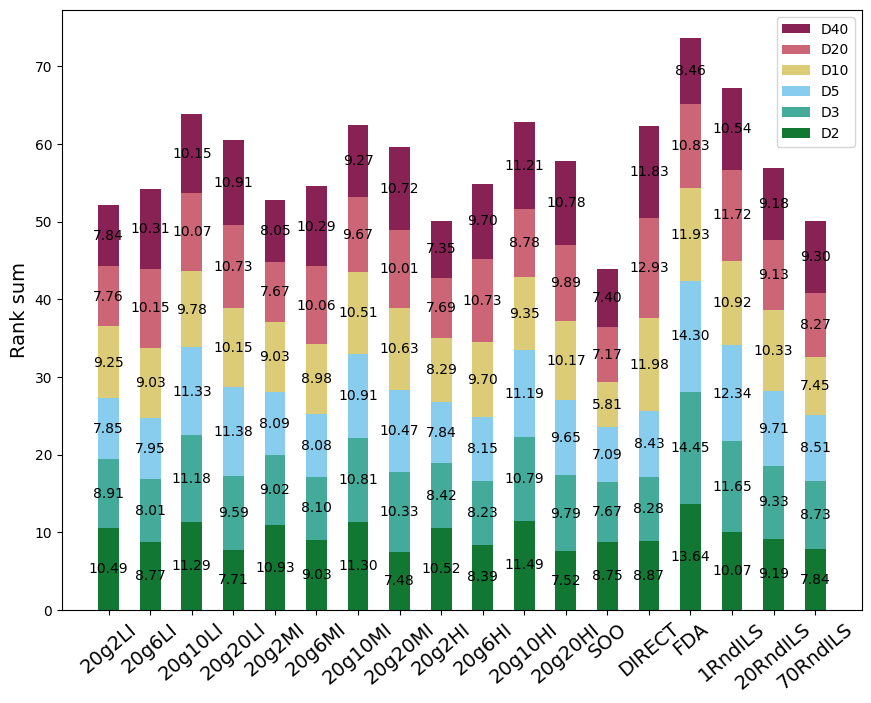

/tmp/ipykernel_18317/2599735875.py:131: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([""] + algos, rotation=90)
/tmp/ipykernel_18317/2599735875.py:132: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([""] + algos, rotation=0)


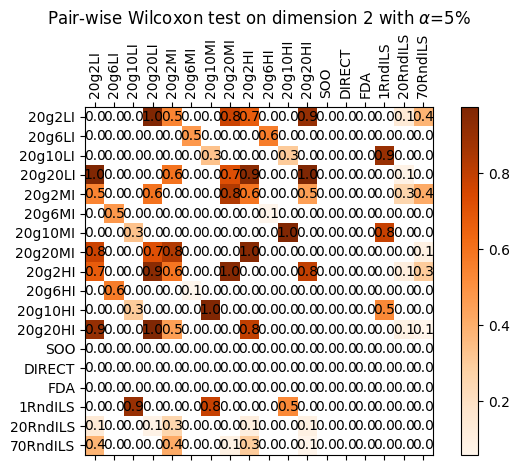

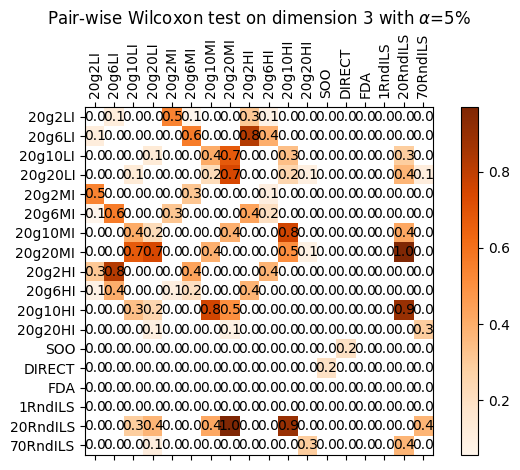

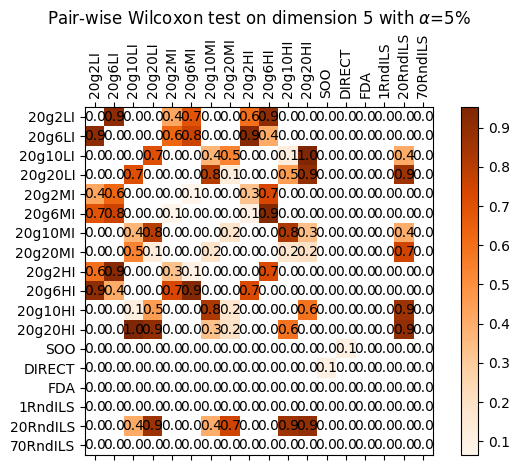

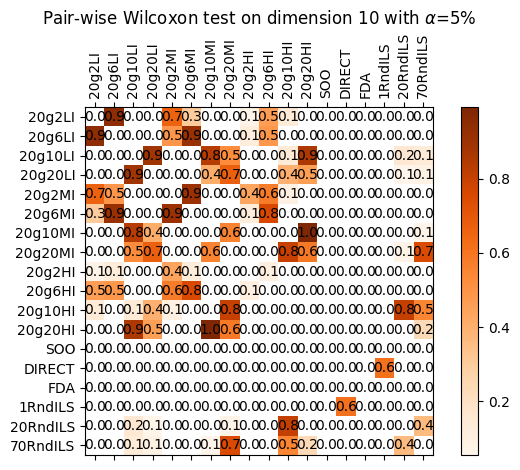

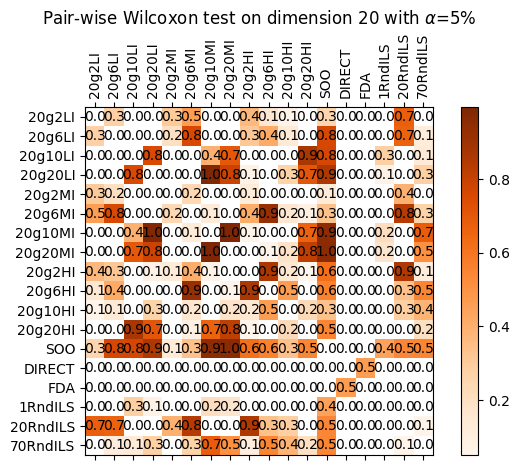

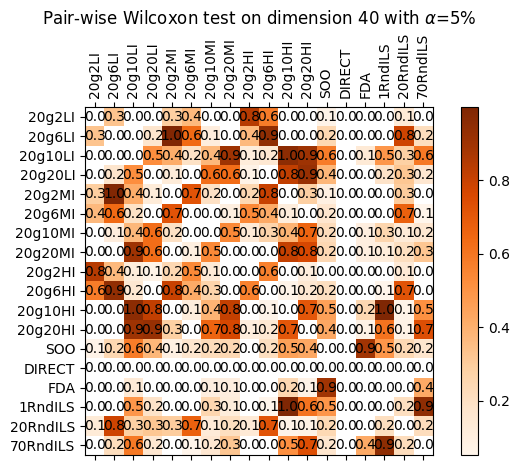

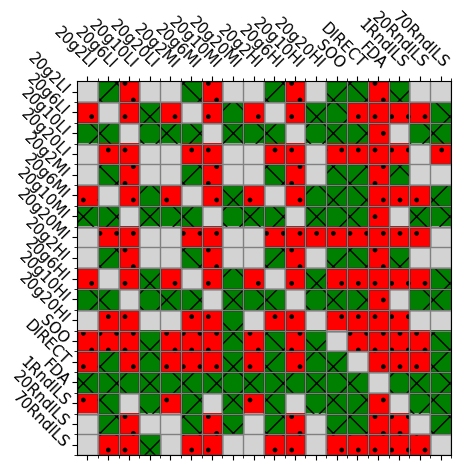

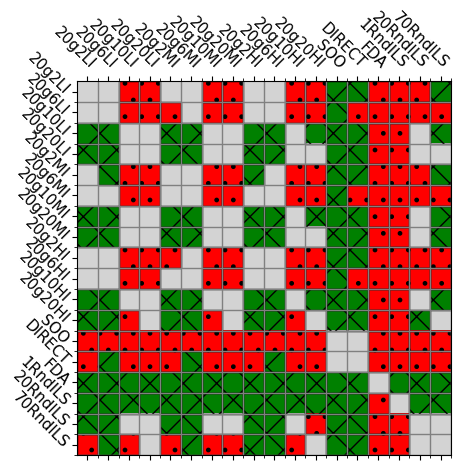

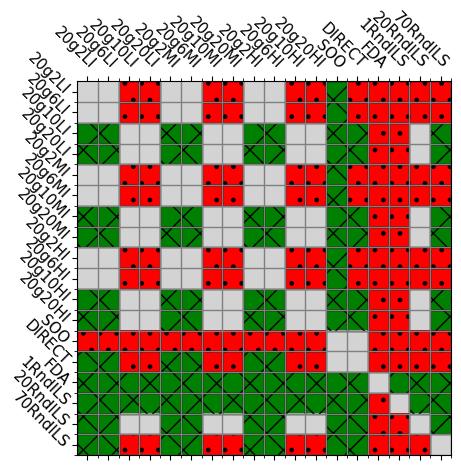

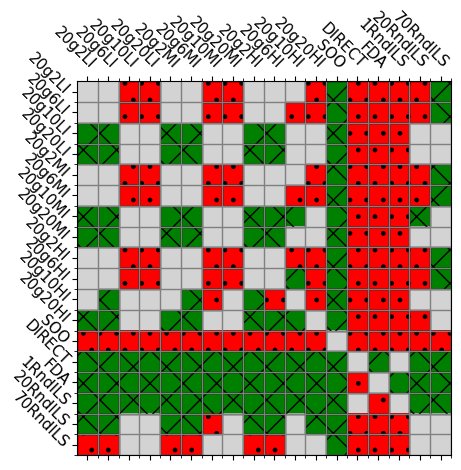

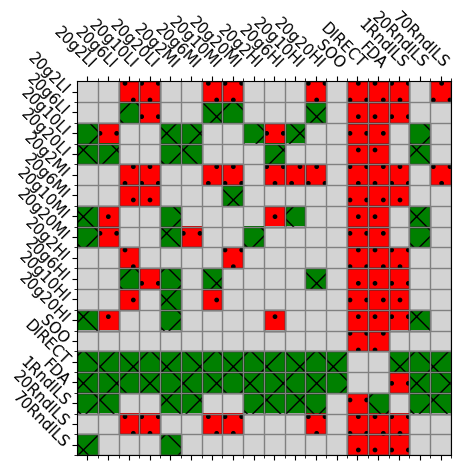

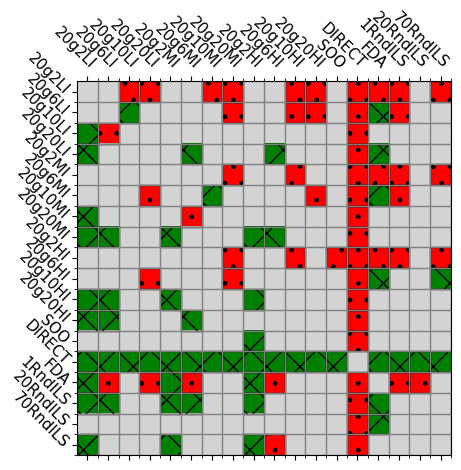

In [44]:
import numpy as np

rank = []
for d in dimensions:
    sub1 = df2.loc[:, ([d], algos)]
    sub1.columns = sub1.columns.droplevel()
    rank.append(sub1.loc[(1, 1)].rank())
    for f in func:
        for i in inst:
            if f != 0 or i != 1:
                if not np.all(np.isfinite(sub1.loc[(f, i), :])):
                    print(sub1.loc[(f, i), :])
                rank[-1] += sub1.loc[(f, i), :].rank()
    rank[-1] /= judges

from scipy import stats

for d in dimensions:
    t1 = df2.loc[:, ([d], algos)]
    t1.columns = t1.columns.droplevel()
    groups = []
    for g in algos:
        groups.append(t1[g])
    res = stats.friedmanchisquare(*groups)
    print(res)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

N = len(algos)
ind = np.arange(N)  # the x locations for the groups
width = 0.50
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0, 0, 1, 1])

# Get the "viridis" colormap
cmap = plt.get_cmap("tab10")

# Create an array of equally spaced values between 0 and 1
color_values = np.linspace(0, 1, 6)

# Get the corresponding colors from the colormap
colors = [cmap(value) for value in color_values]

ax.bar(ind, rank[0], width, color="#117733", label="D2")
ax.bar(ind, rank[1], width, bottom=rank[0], color="#44AA99", label="D3")
ax.bar(ind, rank[2], width, bottom=rank[0] + rank[1], color="#88CCEE", label="D5")
ax.bar(
    ind,
    rank[3],
    width,
    bottom=rank[0] + rank[1] + rank[2],
    color="#DDCC77",
    label="D10",
)
ax.bar(
    ind,
    rank[4],
    width,
    bottom=rank[0] + rank[1] + rank[2] + rank[3],
    color="#CC6677",
    label="D20",
)
ax.bar(
    ind,
    rank[5],
    width,
    bottom=rank[0] + rank[1] + rank[2] + rank[3] + rank[4],
    color="#882255",
    label="D40",
)

for c in ax.containers:
    # Optional: if the segment is small or 0, customize the labels
    labels = ["{:.2f}".format(v.get_height()) if v.get_height() > 0 else "" for v in c]

    # remove the labels parameter if it's not needed for customized labels
    ax.bar_label(c, labels=labels, label_type="center")

ax.set_ylabel("Rank sum", fontsize=14)
# ax.set_title('Ranked sum for SOCO2011')
ax.set_xticks(
    ind,
    algos,
    fontsize=14,
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels))
plt.xticks(rotation=40)
plt.savefig(f"{f_type}_coco_rank.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

stat_w = np.zeros((len(dimensions), N, N))
p_value_w = np.zeros((len(dimensions), N, N))
for k, d in enumerate(dimensions):
    t1 = df2.loc[:, ([d], algos)]
    t1.columns = t1.columns.droplevel()
    for i, g1 in enumerate(algos):
        for j, g2 in enumerate(algos):
            if g1 != g2:
                stat_w[k, i, j], p_value_w[k, i, j] = stats.wilcoxon(
                    t1[g1], t1[g2], zero_method="zsplit"
                )

stat_f = np.zeros((len(dimensions)))
p_value_f = np.zeros((len(dimensions)))
for k, d in enumerate(dimensions):
    t1 = df2.loc[:, ([d], algos)]
    t1.columns = t1.columns.droplevel()
    groups = [t1[g1] for g1 in algos]
    stat_f[k], p_value_f[k] = stats.friedmanchisquare(*groups)

from matplotlib.ticker import MultipleLocator
import matplotlib

for i, d in enumerate(dimensions):
    fig, ax = plt.subplots()

    cmap = matplotlib.cm.Oranges
    cmap.set_bad(color="white")
    masked_array = np.ma.masked_where(p_value_w[i] < 0.05, p_value_w[i])
    cax = ax.matshow(masked_array, cmap=cmap)
    fig.colorbar(cax)
    for (i, j), z in np.ndenumerate(p_value_w[i]):
        ax.text(j, i, "{:0.1f}".format(z), ha="center", va="center")

    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.set_xticklabels([""] + algos, rotation=90)
    ax.set_yticklabels([""] + algos, rotation=0)
    ax.set_title(rf"Pair-wise Wilcoxon test on dimension {d} with $\alpha$=5%")
    fig.tight_layout()
    plt.savefig(f"{f_type}_coco_wilc_d{d}.png", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import matplotlib.patches as mpatches

for i, d in enumerate(dimensions):
    colors_matrix = np.zeros((len(rank[i]), len(rank[i])))
    greater = np.greater.outer(rank[i].to_numpy(), rank[i].to_numpy())
    colors_matrix = np.where(greater, 1, colors_matrix)
    lower = np.less.outer(rank[i].to_numpy(), rank[i].to_numpy())
    colors_matrix = np.where(lower, -1, colors_matrix)
    colors_matrix = np.where(p_value_w[i] > 0.05, 0, colors_matrix)

    cmap = ListedColormap(["red", "lightgrey", "green"])
    fig, ax = plt.subplots()
    cax = ax.matshow(colors_matrix, cmap=cmap)

    # Define hatches for specific values
    hatch_values = {-1: ".", 1: "x"}

    # Get the current axes
    ax = plt.gca()

    # Loop through the data and add hatches
    for i in range(colors_matrix.shape[0]):
        for j in range(colors_matrix.shape[1]):
            value = colors_matrix[i, j]
            if value in hatch_values:
                ax.add_patch(
                    plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        fill=False,
                        hatch=hatch_values[value],
                        edgecolor="black",
                    )
                )

    x = np.arange(0,len(algos),1)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.set_xticks(x, algos, rotation=-45, fontsize=11, ha='right', rotation_mode='anchor')
    ax.set_yticks(x, algos, rotation=-45, fontsize=11, ha='right', rotation_mode='anchor')
    # ax.set_title(f"Ranks and Pair Wise Wilcoxon test comparison\nfor n={d}")
    fig.tight_layout()

    # Minor ticks
    minor_locator = AutoMinorLocator(2)
    ax.xaxis.set_minor_locator(minor_locator)
    ax.yaxis.set_minor_locator(minor_locator)

    ax.grid(which="minor", color="grey", linestyle="-", linewidth=1)
    # plt.arrow(
    #     len(algos)+.1,
    #     -0.5,
    #     0,
    #     5.5,
    #     head_width=0,
    #     head_length=0,
    #     linewidth=2,
    #     color="black",
    #     length_includes_head=True,
    #     clip_on=False,
    # )
    # plt.arrow(
    #     len(algos) + 0.1,
    #     5,
    #     -0.8,
    #     0,
    #     head_width=0,
    #     head_length=0,
    #     linewidth=2,
    #     color="black",
    #     length_includes_head=True,
    #     clip_on=False,
    # )
    # plt.arrow(
    #     len(algos)-.5,
    #     5,
    #     -0.45,
    #     0,
    #     head_width=0.2,
    #     head_length=0.2,
    #     linewidth=2,
    #     color="white",
    #     length_includes_head=True,
    #     clip_on=False,
    # )
    # plt.annotate(
    #     "DIRECT-L vs SOO",
    #     xy=(len(algos)-0.8, 3.7),
    #     xytext=(len(algos)-1, -(len(algos)-1)),
    #     textcoords="offset points",
    #     rotation=90,
    # )

    # patches = [
    #     mpatches.Patch(
    #         color="lightgrey", label="Unsignificative\n" + r"($\alpha>5\%$)"
    #     ),
    #     mpatches.Patch(color="green", label="Better", hatch="xxx"),
    #     mpatches.Patch(color="red", label="Worse", hatch="..."),
    # ]
    # plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
    ax.set_xlim((-0.5,len(algos)-.5))
    ax.set_ylim((len(algos)-.5 ,- 0.5))
    plt.savefig(
        f"{f_type}_coco_compar{d}.png",
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor(),
    )
    plt.show()
    plt.close(fig)